# Dataset A — Breast Cancer Dataset

In [35]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
data = load_breast_cancer()


# Q1 — Dataset Exploration and Understanding

## 1. Construct the feature matrix X and target vector y.

In [36]:
from sklearn.model_selection import train_test_split
X = data['data']
Y = data['target']
features_train, features_test, labels_train, labels_test = train_test_split(
    X, Y, test_size=0.33, random_state=42
)

##  2. Report the shape of X and y

In [37]:
print(X.shape, Y.shape)

(569, 30) (569,)


## 3. Report the number of samples belonging to each class

In [38]:
for i,j in zip(data.target_names, np.unique(data.target)):
    print(i,(Y == j).sum())

malignant 212
benign 357


## 4. Discussion

In [39]:
total = 212 + 357
malignant_percentage = 212/total
bening_percentage = 357/total
print('Malignant (%)',malignant_percentage* 100, '%')
print('Bening (%)', bening_percentage*100,'%')

Malignant (%) 37.258347978910365 %
Bening (%) 62.741652021089635 %


#### 4.1. whether the dataset is balanced or imbalanced

I would say that the dataset is midly imbalanced becaus its distribution is nearly 60/40 whereas if it were completly balanced the distribution would approach more to 50/50
<br>
#### 4.2. why class balance is an important consideration for classification models
Having a balanced dataset is important because an imbalanced dataset can mislead the model and the evaluation results. Because if it is highly unbalanced it could predict the majority class perfectly with accuracy whilst poorly predicting the minority class as it was a small aprt of the dataset.

# Q2 — Decision Tree Model Using Entropy

## 1. Train a Decision Tree classifier using entropy as the splitting criterion

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier( criterion='entropy', random_state=42)
tree.fit(features_train, labels_train)
train_prediction = tree.predict(features_train)
test_prediction = tree.predict(features_test)


## 2. Report the training accuracy and test accuracy of the model.

In [41]:
train_accuracy = accuracy_score(labels_train, train_prediction)
test_accuracy = accuracy_score(labels_test, test_prediction)

print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

Training accuracy: 1.0
Test accuracy: 0.9468085106382979


## 3. what entropy represents in the context of decision trees

Entropy measures how good is a partition in a node of a decision tree where low values represent a better partition.
<br>
### 4. whether the observed results suggest overfitting or good generalization

a. In the case of the training data as we didn't set an optimal tree depth it created multiple branches that are really good at predincting the observed data (accuracy of 1) but fails to generalize the unseen data (accuracy of 0.94) so out model is overfitted as it fails to catch the patterns in unseen data.

# Q3 — Controlling Tree Complexity and Interpretability

## 1. Train the constrained model and report training and test accuracy.

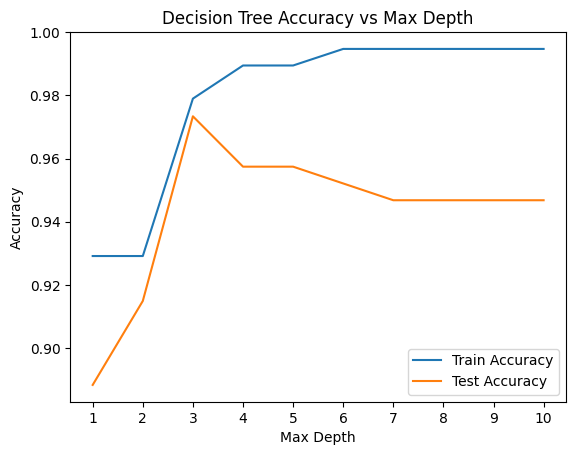

In [42]:
max_depth_values = list(range(1, 11))

train_accuracies = []
test_accuracies = []

for depth in max_depth_values:
    decision_tree_classifier = DecisionTreeClassifier(     criterion='entropy',min_impurity_decrease=0.01,min_samples_split=2,max_depth=depth,random_state=42)

    decision_tree_classifier.fit(features_train, labels_train)
    train_predictions = decision_tree_classifier.predict(features_train)
    test_predictions = decision_tree_classifier.predict(features_test)
    train_accuracy = accuracy_score(labels_train, train_predictions)
    test_accuracy = accuracy_score(labels_test, test_predictions)
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)


plt.figure()
plt.plot(max_depth_values, train_accuracies, label='Train Accuracy')
plt.plot(max_depth_values, test_accuracies, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.xticks(max_depth_values)
plt.legend()

plt.show()

The optimal depth for the model is 3 as it is shown in the graph

## 2. Display the top five most important features according to the model

In [43]:

feature_importances = decision_tree_classifier.feature_importances_

feature_importance_dataframe = pd.DataFrame({
    'feature_name': data.feature_names,
    'importance': feature_importances
})

top_five_features = feature_importance_dataframe.sort_values(
    by='importance',
    ascending=False
).head(5)

top_five_features

,feature_name,importance
7,mean concave points,0.631782
21,worst texture,0.098686
22,worst perimeter,0.096801
20,worst radius,0.072205
27,worst concave points,0.024734


## 3. how controlling model complexity affects overfitting

If we don't control the complexity of the model this will result in many splits which creates a tree with numerous
leaf nodes each including only one or few samples with a similar class. SUch tree would predict perfectly our train data but will fail in generalizing new data that is even similar to the trainning set.
<br>
## 4. how feature importance contributes to the interpretability of decision trees

# Q4 — Neural Network for Binary Classification

## 1. Standardize the input features

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)


## 2. Train a neural network with at least one hidden layer and a sigmoid output unit.

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
tf.random.set_seed(1)
neural_network_model = Sequential()
input_layer =InputLayer(shape=(30,))
neural_network_model.add(input_layer)
hidden_layer = Dense(3)
neural_network_model.add(hidden_layer)
second_hidden_layer = Dense(5)
neural_network_model.add(second_hidden_layer)
third_hidden_layer = Dense(2)
neural_network_model.add(third_hidden_layer)
output_layer = Dense(1, activation='sigmoid')
neural_network_model.add(output_layer)
neural_network_model.compile(loss='binary_crossentropy')

In [46]:
neural_network_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [47]:
neural_network_model.fit(features_train, labels_train, epochs=100)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4436 - loss: 24.9153
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3255 - loss: 12.6356 
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1759 - loss: 9.3576  
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1654 - loss: 8.9379  
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2021 - loss: 7.2573 
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1732 - loss: 6.2236 
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1942 - loss: 5.2438 
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1864 - loss: 4.2670 
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1969 - loss: 3.3865 
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2205 - loss: 2.7234 
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3360 - loss: 2.2288 
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/st

## 3. Report training accuracy and test accuracy

In [48]:
train_loss, train_accuracy = neural_network_model.evaluate(features_train, labels_train)
test_loss, test_accuracy = neural_network_model.evaluate(features_test, labels_test)

print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8871 - loss: 0.2759  
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9255 - loss: 0.1612 
Training accuracy: 0.887139081954956
Test accuracy: 0.9255319237709045


## 4. why feature scaling is necessary for neural networks
it ensures that all input features contribute equally to the learning process and helps the model train more efficiently. So scaling the feutures permits all feature to be within a similar scale and prevents that features tha have a big range from deviating the results
<br>
## 5. what an epoch represents during neural network training

It's the number of iterations the data passes through a neural network. A epoch would be completesd once the output values, validate the predicted and Update the weights and biases.

# Q5 — Model Evaluation and Comparison

## 1. Compute and display the confusion matrix for each model

In [49]:
from sklearn.metrics import confusion_matrix



tree_test_predictions = decision_tree_classifier.predict(features_test)
decision_tree_confusion_matrix = confusion_matrix(labels_test, tree_test_predictions)
decision_tree_confusion_matrix = confusion_matrix(labels_test, tree_test_predictions)

print("Decision Tree Confusion Matrix:")
print(decision_tree_confusion_matrix)

Decision Tree Confusion Matrix:
[[ 59   8]
 [  2 119]]


In [50]:
neural_network_test_predictions = (neural_network_model.predict(features_test))
neural_network_test_predictions = (neural_network_model.predict(features_test) > 0.5).astype(int)
neural_network_confusion_matrix = confusion_matrix(labels_test, neural_network_test_predictions)

print("\nNeural Network Confusion Matrix:")
print(neural_network_confusion_matrix)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Neural Network Confusion Matrix:
[[ 53  14]
 [  0 121]]


## 3. which model you would prefer for this task

I would prefer the neural network here, because it makes fewer false positives and has a higher overall accuracy (0.96). WHilst the 2 models have the same number of false negatives.
<br>
## 4. one advantage and one limitation of each mode
### 4.1 Decision Tree:
- **Advantage:** It's easy to interpret. As we can se the partitions of the tree and how the final prediction is done.
- **Disadvantage:** It's easy to overfit the data if we don't control the complexity of the model.

### 4.2. Neural Networks:
- **Advantage:** It captures complex patter in the data. Thus might do better predictions.
- **Disadvantage:** It's often a blackbox, so it is not easy to interpret how it reached a certain prediction.


# Dataset B — Fashion MNIST (for CNN)

In [51]:
from tensorflow . keras . datasets import fashion_mnist
( X_train , y_train ) , ( X_test , y_test ) = fashion_mnist . load_data ()

# Q6 — Convolutional Neural Network with Built-in Dataset

##  1. Load the Fashion MNIST dataset

In [52]:
from tensorflow . keras . datasets import fashion_mnist
( X_train , y_train ) , ( X_test , y_test ) = fashion_mnist . load_data ()

## 2. Normalize the pixel values to the range [0,1]

In [53]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## 3. Reshape the images to include the channel dimension

In [54]:
X_train = X_train[..., None]
X_test = X_test[..., None]

# 4. Build a CNN

In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
  layers.Input(shape=(28, 28, 1)),
  layers.Conv2D(16, 3, padding="same", activation="relu"),
  layers.MaxPool2D(),
  layers.Conv2D(32, 3, padding="same", activation="relu"),
  layers.MaxPool2D(),
])
model.add(layers.Flatten())
model.add(layers.Dense(128, activation="relu"))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,922 (808.29 KB)

 Trainable params: 206,922 (808.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the model for at least 15 epochs

In [56]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.8058 - loss: 0.5388 - val_accuracy: 0.8722 - val_loss: 0.3441
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.8725 - loss: 0.3527 - val_accuracy: 0.8910 - val_loss: 0.3028
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.8877 - loss: 0.3073 - val_accuracy: 0.8978 - val_loss: 0.2747
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8971 - loss: 0.2814 - val_accuracy: 0.9038 - val_loss: 0.2559
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9061 - loss: 0.2557 - val_accuracy: 0.9082 - val_loss: 0.2456
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 34s 41ms/step - accuracy: 0.9107 - loss: 0.2416 - val_accuracy: 0.9075 - val_loss: 0.2429
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.9175 - loss: 0.2237 - val_accuracy: 0.9098 - val_loss: 0.2354
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.9227 - loss: 0.2087 - 

## 6. Report the test accuracy.

In [57]:
test_loss, test_acc = model.evaluate( X_test, y_test, verbose=0)

print("test loss:", test_loss)
print("test acc:", test_acc)

test loss: 0.26357147097587585
test acc: 0.9125000238418579


## 7. why CNNs are generally preferred over fully connectcaned networks for image data
Because for regular NN it is specting to recieve a vector, so the RGB channels have to be flatten and this provokes that the spatial layout gets destroyed and also created too many parameters.
<b>
## 8. what the convolution layer is learning in this task

In this task, the convolutional layers of the CNN are learning to extract spatial patterns from the data.

 # Q7 — CNN Error Analysis and Misclassification Study

## 1. Generate predictions on the test set

In [58]:
test_predictions_prob = model.predict(X_test)

test_predictions = test_predictions_prob.argmax(axis=1)

print("Predictions", test_predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predictions [9 2 1 ... 8 1 7]


##  2. Compute and display the confusion matrix

In [59]:

con_matrix = confusion_matrix(y_test, test_predictions)
pd.DataFrame(
    con_matrix,
    index=[f"Real Image {i}" for i in range(10)],
    columns=[f"Predicted Image {i}" for i in range(10)]
)


,Predicted Image 0,Predicted Image 1,Predicted Image 2,Predicted Image 3,Predicted Image 4,Predicted Image 5,Predicted Image 6,Predicted Image 7,Predicted Image 8,Predicted Image 9
Real Image 0,821,0,23,18,5,0,126,0,7,0
Real Image 1,0,979,1,14,2,0,2,0,2,0
Real Image 2,11,1,890,5,50,0,41,0,2,0
Real Image 3,12,4,19,909,22,0,34,0,0,0
Real Image 4,0,0,54,22,886,0,38,0,0,0
Real Image 5,0,0,0,0,0,991,0,8,0,1
Real Image 6,70,1,72,29,80,0,741,0,7,0
Real Image 7,0,0,0,0,0,10,0,971,0,19
Real Image 8,5,1,1,2,3,2,2,1,983,0
Real Image 9,0,0,1,0,0,7,0,38,0,954


## 3.Identify and visualize at least three misclassified images

In [60]:
misclassified_indices = np.where(y_test != test_predictions)[0]
first_three_indices = misclassified_indices[:3]

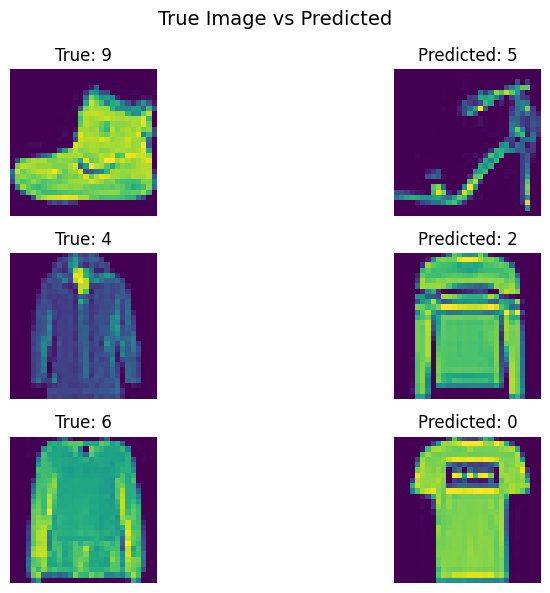

In [64]:
class_to_images = {}
for i in range(10):
    class_to_images[i] = X_train[y_train == i]

plt.figure(figsize=(10, 6))

for i in range(len(first_three_indices)):
    idx = first_three_indices[i]

    true_class = y_test[idx]
    predicted_class = test_predictions[idx]

    true_images_for_class = class_to_images[true_class]
    true_image = true_images_for_class[0]
    true_image = true_image.reshape(28, 28)

    predicted_images_for_class = class_to_images[predicted_class]
    predicted_image = predicted_images_for_class[0]
    predicted_image = predicted_image.reshape(28, 28)

    plot_position_left = 2 * i + 1
    plt.subplot(3, 2, plot_position_left)
    plt.imshow(true_image)
    plt.title("True: " + str(true_class))
    plt.axis('off')

    plot_position_right = 2 * i + 2
    plt.subplot(3, 2, plot_position_right)
    plt.imshow(predicted_image)
    plt.title("Predicted: " + str(predicted_class))
    plt.axis('off')

plt.suptitle("True Image vs Predicted" , fontsize=14)
plt.tight_layout()
plt.show()

## 4. One pattern you observe in the misclassifications
Shirt (6)  gets constantly a bad prediction and it gets confussed with  Pullover (2), Dress (3), Coat (4), and Shirt (6). SO it seems the model is pretty bad into determining upper body clothing because they are too similar and have similar shapes.
<br>
## 5. one realistic method to improve the CNN performance

Maybe showing the upper garment in different angles and positions would help the model to detect better the smmal patter on the clothing like sleeves and neck shape.